# Solution: Classify Wines with a Tree vs. a Forest 🍷

Predict which of **three cultivars** (`target` = 0/1/2) produced each wine, from 13 chemical measurements — comparing a **Decision Tree** and a **Random Forest**.

## Step 1 — Load the data

In [1]:
import pandas as pd

df = pd.read_csv('wine.csv')
print('shape:', df.shape)
df.head()

shape: (178, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


## Step 2 — Get to know the data

In [2]:
print('class counts:')
print(df['target'].value_counts().sort_index())
print('\nmissing values:', df.isnull().sum().sum())

class counts:
target
0    59
1    71
2    48
Name: count, dtype: int64

missing values: 0


## Step 3 — Features (X) and target (y)

In [3]:
X = df.drop(columns='target')
y = df['target']
print('features:', X.shape[1])

features: 13


## Step 4 — Train / test split

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print('train:', X_train.shape[0], ' test:', X_test.shape[0])

train: 142  test: 36


## Step 5 — Model 1: Decision Tree

In [5]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

print('train accuracy:', round(tree.score(X_train, y_train), 3))
print('test accuracy: ', round(tree.score(X_test, y_test), 3))
print(classification_report(y_test, tree.predict(X_test),
                            target_names=['class_0', 'class_1', 'class_2']))

train accuracy: 1.0
test accuracy:  0.944
              precision    recall  f1-score   support

     class_0       1.00      0.92      0.96        12
     class_1       0.88      1.00      0.93        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.96      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



## Step 6 — Model 2: Random Forest

In [6]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(n_estimators=100, random_state=42)
forest.fit(X_train, y_train)

print('test accuracy:', round(forest.score(X_test, y_test), 3))
print(classification_report(y_test, forest.predict(X_test),
                            target_names=['class_0', 'class_1', 'class_2']))

test accuracy: 1.0
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



## Step 7 — Experiment: how many trees?

  1 trees -> test accuracy = 0.917
 10 trees -> test accuracy = 1.000
 50 trees -> test accuracy = 1.000
100 trees -> test accuracy = 1.000


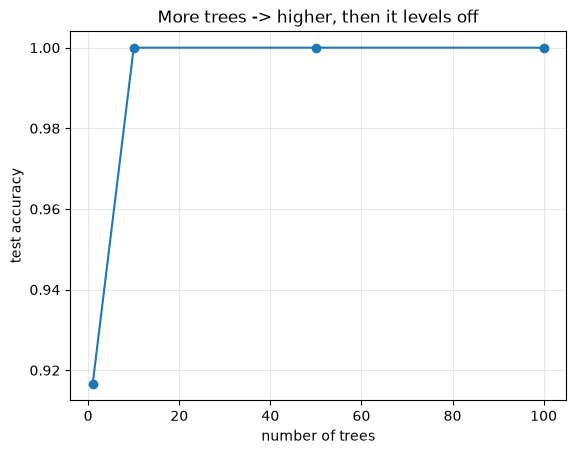

In [7]:
import matplotlib.pyplot as plt

tree_counts = [1, 10, 50, 100]
test_acc = []
for n in tree_counts:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    acc = rf.score(X_test, y_test)
    test_acc.append(acc)
    print(f'{n:>3} trees -> test accuracy = {acc:.3f}')

plt.plot(tree_counts, test_acc, 'o-')
plt.xlabel('number of trees'); plt.ylabel('test accuracy')
plt.title('More trees -> higher, then it levels off'); plt.grid(alpha=0.3)
plt.show()

## Step 8 — Conclusions

1. **The Random Forest won** — test accuracy 1.0 vs. ~0.94 for the single tree.
2. **Yes, the tree overfit** — training accuracy was 1.0 while test accuracy was lower (~0.94).
3. Accuracy jumped from 1 tree (~0.92) to 10 trees (1.0), then **stayed flat** — more trees gave no further gain here.

## Bonus — feature importances

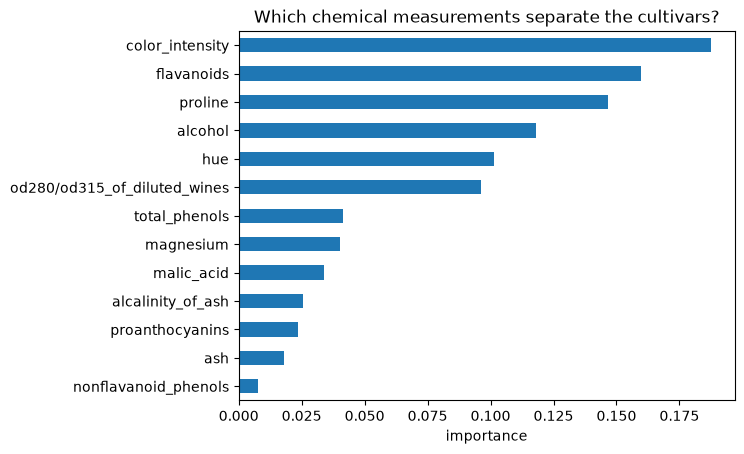

In [8]:
importances = pd.Series(forest.feature_importances_, index=X.columns).sort_values()
importances.plot(kind='barh')
plt.xlabel('importance')
plt.title('Which chemical measurements separate the cultivars?')
plt.show()